# 06 - Event Study

This notebook tests whether the anomaly flags produced by the three detectors carry real economic information, or whether flagged days are simply riding broader market moves. It does this with a standard event study: for each stock-day flagged by exactly one detector (using the single-detector sets from notebook 05), it computes the cumulative abnormal return (CAR) over the days that follow, where "abnormal" means beyond what a Fama-French three-factor model would predict for that stock.

The approach:
1. Estimate each stock's factor betas by regressing its daily returns on the Fama-French factors (market, size, value) over the full 2015-2025 history.
2. Use those betas to compute each stock's expected return on every day.
3. Abnormal return = actual return minus expected return, for each day.
4. CAR = the sum of abnormal returns over the 5, 10, or 20 trading days following a flagged day.

If a detector's flags are followed by systematically nonzero CARs, that flag is picking up something the market hadn't already priced in: evidence the detector carries genuine economic signal rather than just noise.

**Outputs**
- `data/factor_betas.parquet`, each stock's estimated alpha and factor loadings (market, size, value)
- `data/abnormal_returns.parquet`, daily abnormal return for every stock, 2015-2025
- `data/event_study_results.csv`, mean CAR and significance test for each detector's unique flags, at 5/10/20-day windows
- `data/event_study_two_sample.csv`, two-sample tests comparing Isolation Forest-only CARs against ±3σ-only CARs
- `results/event_study_car_paths.png`, the average cumulative abnormal return path after each detector's unique flags

## 1. Fetching the Fama-French Factors

Download the daily Fama-French three-factor data (market, size, value, and the risk-free rate) for 2015-2025. These factors are the benchmark against which "expected" returns are computed.

In [1]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr

# Fama-French 3 factors, daily
ff = pdr.DataReader(
    "F-F_Research_Data_Factors_daily",
    "famafrench",
    start="2015-01-01",
    end="2025-01-01",
)

print(type(ff))
print(ff.keys() if hasattr(ff, "keys") else "single frame")

<class 'dict'>
dict_keys([0, 'DESCR'])


In [2]:
factors = ff[0]
print("Shape:", factors.shape)
print("\nColumns:", list(factors.columns))
print("\nFirst rows:")
print(factors.head())
print("\nLast rows:")
print(factors.tail())

Shape: (2516, 4)

Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']

First rows:
            Mkt-RF   SMB   HML   RF
Date                               
2015-01-02   -0.12 -0.59  0.12  0.0
2015-01-05   -1.84  0.33 -0.67  0.0
2015-01-06   -1.03 -0.79 -0.29  0.0
2015-01-07    1.19  0.20 -0.67  0.0
2015-01-08    1.81 -0.11 -0.29  0.0

Last rows:
            Mkt-RF   SMB   HML    RF
Date                                
2024-12-24    1.11 -0.09 -0.05  0.02
2024-12-26    0.01  1.03 -0.18  0.02
2024-12-27   -1.17 -0.65  0.55  0.02
2024-12-30   -1.09  0.13  0.74  0.02
2024-12-31   -0.46  0.02  0.71  0.02


In [3]:
print("Sample Mkt-RF values:", factors["Mkt-RF"].head().values)
print("If these look like -1.5 to +1.5, they're in PERCENT and need /100")

Sample Mkt-RF values: [-0.12 -1.84 -1.03  1.19  1.81]
If these look like -1.5 to +1.5, they're in PERCENT and need /100


### Units mismatch

The Fama-French factors are expressed in percent (for example, 1.11 means 1.11%), while the log returns computed elsewhere in this project are in decimal form. Combining the two without converting to a common unit would make every abnormal return off by a factor of 100.

In [4]:
factors = factors / 100.0

print("After scaling to decimals:")
print(factors.head())
print("\nSample Mkt-RF values:", factors["Mkt-RF"].head().values)

After scaling to decimals:
            Mkt-RF     SMB     HML   RF
Date                                   
2015-01-02 -0.0012 -0.0059  0.0012  0.0
2015-01-05 -0.0184  0.0033 -0.0067  0.0
2015-01-06 -0.0103 -0.0079 -0.0029  0.0
2015-01-07  0.0119  0.0020 -0.0067  0.0
2015-01-08  0.0181 -0.0011 -0.0029  0.0

Sample Mkt-RF values: [-0.0012 -0.0184 -0.0103  0.0119  0.0181]


## 2. Estimating Factor Betas

Each stock's expected return is modeled with the Fama-French three-factor equation:

`stock_return = α + β_mkt · (Mkt-RF) + β_smb · SMB + β_hml · HML + error`

The betas are estimated separately for each stock by regressing its excess return on the three factors over its full history.

In [6]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm

DATA_DIR = Path("../data")

# the feature matrix holds ret_zscore, not raw log returns; those need to be recomputed from price data
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")
print(features.columns.tolist())
print(features.head())

['ret_zscore', 'vol_5', 'vol_20', 'vol_60', 'vol_zscore']
                   ret_zscore     vol_5    vol_20    vol_60  vol_zscore
Date       Ticker                                                      
2015-03-31 A        -0.265173  0.010081  0.012668  0.014717   -0.410469
           AAPL     -0.938536  0.020079  0.014414  0.017461   -0.650943
           ABBV      0.313154  0.015403  0.019325  0.020973   -0.017244
           ABT      -1.348182  0.009937  0.011308  0.011799    0.387669
           ACGL     -2.030660  0.011328  0.009421  0.008541    2.016447


In [7]:
# load the clean price data
prices = pd.read_parquet(DATA_DIR / "sp500_ohlcv_2015_2025_clean.parquet")
close = prices["Close"]

# raw daily log returns (same formula as notebook 01)
log_returns = np.log(close / close.shift(1))

print("Log returns shape:", log_returns.shape)
print("Sample (AAPL):", log_returns["AAPL"].dropna().head().values)

Log returns shape: (2516, 499)
Sample (AAPL): [-2.85759947e-02  9.42635060e-05  1.39246501e-02  3.77026727e-02
  1.07184798e-03]


In [8]:
# align returns and factors on shared dates
common_dates = log_returns.index.intersection(factors.index)
rets = log_returns.loc[common_dates]
facs = factors.loc[common_dates]

# design matrix: the three factors + a constant (for alpha)
X = sm.add_constant(facs[["Mkt-RF", "SMB", "HML"]])

betas = {}
for ticker in rets.columns:
    y = rets[ticker] - facs["RF"]      # excess return of the stock
    data = pd.concat([y.rename("y"), X], axis=1).dropna()   # drop days with missing data
    if len(data) < 100:                # need enough days for a stable regression
        continue
    model = sm.OLS(data["y"], data[X.columns]).fit()
    betas[ticker] = {
        "alpha": model.params["const"],
        "b_mkt": model.params["Mkt-RF"],
        "b_smb": model.params["SMB"],
        "b_hml": model.params["HML"],
    }

betas_df = pd.DataFrame(betas).T
print("Estimated betas for", len(betas_df), "stocks")
print(betas_df.head())

Estimated betas for 0 stocks
Empty DataFrame
Columns: []
Index: []


### Diagnosing zero estimated stocks

The regression loop above ran without error but produced betas for zero stocks, meaning every stock had fewer than 100 overlapping data points with the factors after dropping missing rows. This points to a date-alignment problem between the return series and the factor series rather than a modeling issue, so the index types of each are checked directly below.

In [9]:
print("log_returns index type:", type(log_returns.index))
print("log_returns first 3 dates:", log_returns.index[:3].tolist())
print("log_returns dtype:", log_returns.index.dtype)
print()
print("factors index type:", type(factors.index))
print("factors first 3 dates:", factors.index[:3].tolist())
print("factors dtype:", factors.index.dtype)
print()
print("Overlapping dates:", len(log_returns.index.intersection(factors.index)))

log_returns index type: <class 'pandas.DatetimeIndex'>
log_returns first 3 dates: [Timestamp('2015-01-02 00:00:00'), Timestamp('2015-01-05 00:00:00'), Timestamp('2015-01-06 00:00:00')]
log_returns dtype: datetime64[ms]

factors index type: <class 'pandas.PeriodIndex'>
factors first 3 dates: [Period('2015-01-02', 'D'), Period('2015-01-05', 'D'), Period('2015-01-06', 'D')]
factors dtype: period[D]

Overlapping dates: 0


The factors are indexed by a `PeriodIndex` (daily periods) while the returns are indexed by a `DatetimeIndex` (timestamps). Even though the underlying dates match, pandas treats these as different index types, so `.intersection()` finds zero overlap. Converting the factor index to timestamps should fix the alignment.

In [10]:
factors.index = factors.index.to_timestamp()

print("factors index type now:", type(factors.index))
print("Overlapping dates now:", len(log_returns.index.intersection(factors.index)))

factors index type now: <class 'pandas.DatetimeIndex'>
Overlapping dates now: 2516


With the index types aligned and 2,516 overlapping dates confirmed, the regression can be rerun.

In [11]:
common_dates = log_returns.index.intersection(factors.index)
rets = log_returns.loc[common_dates]
facs = factors.loc[common_dates]

X = sm.add_constant(facs[["Mkt-RF", "SMB", "HML"]])

betas = {}
for ticker in rets.columns:
    y = rets[ticker] - facs["RF"]
    data = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(data) < 100:
        continue
    model = sm.OLS(data["y"], data[X.columns]).fit()
    betas[ticker] = {
        "alpha": model.params["const"],
        "b_mkt": model.params["Mkt-RF"],
        "b_smb": model.params["SMB"],
        "b_hml": model.params["HML"],
    }

betas_df = pd.DataFrame(betas).T
print("Estimated betas for", len(betas_df), "stocks")
print(betas_df.head())
print("\nMarket beta stats:")
print(betas_df["b_mkt"].describe())

Estimated betas for 499 stocks
         alpha     b_mkt     b_smb     b_hml
A    -0.000050  0.991172  0.041858 -0.156767
AAPL  0.000237  1.173816 -0.297036 -0.399828
ABBV  0.000152  0.680637 -0.250812  0.034591
ABNB -0.000553  1.338113  0.680934 -0.353510
ABT  -0.000065  0.843491 -0.302214 -0.172702

Market beta stats:
count    499.000000
mean       0.985300
std        0.281343
min        0.333238
25%        0.794948
50%        0.979906
75%        1.157912
max        2.214706
Name: b_mkt, dtype: float64


## 3. Saving Factor Betas

In [12]:
betas_df.to_parquet(DATA_DIR / "factor_betas.parquet")
print("Saved betas for", len(betas_df), "stocks.")

Saved betas for 499 stocks.


## 4. Computing Abnormal Returns

Using each stock's estimated betas, compute its expected return on every day, then define abnormal return as actual minus expected.

In [13]:
# align everything on common dates
rets = log_returns.loc[common_dates]
facs = factors.loc[common_dates]

# expected EXCESS return for each stock each day, then add RF back for total
# build it stock by stock using each stock's betas
expected = pd.DataFrame(index=common_dates, columns=rets.columns, dtype=float)

for ticker in betas_df.index:
    b = betas_df.loc[ticker]
    exp_excess = (b["alpha"]
                  + b["b_mkt"] * facs["Mkt-RF"]
                  + b["b_smb"] * facs["SMB"]
                  + b["b_hml"] * facs["HML"])
    expected[ticker] = exp_excess + facs["RF"]      # add RF back → total return

abnormal = rets - expected      # actual total − expected total
print("Abnormal returns shape:", abnormal.shape)
print("Sample AAPL abnormal returns:", abnormal["AAPL"].dropna().head().values)

Abnormal returns shape: (2516, 499)
Sample AAPL abnormal returns: [-0.00891371  0.00844119 -0.00236583  0.01473307  0.00893279]


## 5. Saving Abnormal Returns

In [14]:
abnormal.to_parquet(DATA_DIR / "abnormal_returns.parquet")
print("Saved abnormal returns.")

Saved abnormal returns.


## 6. Event Study Setup

Load the disagreement verdicts from notebook 05 and define a function to compute the cumulative abnormal return following a flagged stock-day. CAR is measured starting the day after the flag (day +1) through day +window, since that's the earliest a signal could actually be acted on.

In [15]:
# load the disagreement verdicts from the agreement analysis
verdicts = pd.read_parquet(DATA_DIR / "agreement_verdicts.parquet")

def compute_car(flagged_stockdays, abnormal, window=5):
    """
    For each flagged (date, ticker), sum abnormal returns over the
    NEXT `window` trading days (day +1 through +window). Returns a list of CARs.
    """
    cars = []
    date_index = abnormal.index          # the ordered trading dates
    for (flag_date, ticker) in flagged_stockdays:
        if ticker not in abnormal.columns:
            continue
        # position of the flag date in the trading calendar
        loc = date_index.get_indexer([flag_date])[0]
        if loc == -1:
            continue
        start = loc + 1                  # +1: start the DAY AFTER the flag
        end = loc + 1 + window           # through +window
        if end > len(date_index):        # not enough future days (near end of data)
            continue
        window_abn = abnormal[ticker].iloc[start:end]
        cars.append(window_abn.sum())    # CAR = sum of abnormal returns in window
    return np.array(cars)

## 7. Mean CAR for Each Detector's Unique Flags

Focus on the single-detector-only sets from notebook 05 (`stat_only`, `iso_only`, `lstm_only`), since these are the days where the detectors actually disagree, and therefore the days where a real difference in economic signal would show up.

In [16]:
# extract the flagged stock-days for each single-detector set
s, i, l = verdicts["stat"], verdicts["iso"], verdicts["lstm"]

stat_only  = verdicts[ s & ~i & ~l].index.tolist()
iso_only   = verdicts[~s &  i & ~l].index.tolist()
lstm_only  = verdicts[~s & ~i &  l].index.tolist()

for window in [5, 10, 20]:
    print(f"\n=== {window}-day CAR ===")
    for name, flags in [("stat_only", stat_only), ("iso_only", iso_only), ("lstm_only", lstm_only)]:
        cars = compute_car(flags, abnormal, window=window)
        print(f"{name:10s}: mean CAR = {cars.mean():+.4f}  |  n = {len(cars)}")


=== 5-day CAR ===
stat_only : mean CAR = -0.0010  |  n = 6990
iso_only  : mean CAR = +0.0025  |  n = 7081
lstm_only : mean CAR = -0.0008  |  n = 8064

=== 10-day CAR ===
stat_only : mean CAR = -0.0014  |  n = 6954
iso_only  : mean CAR = +0.0059  |  n = 7076
lstm_only : mean CAR = -0.0017  |  n = 8056

=== 20-day CAR ===
stat_only : mean CAR = -0.0024  |  n = 6938
iso_only  : mean CAR = +0.0070  |  n = 7060
lstm_only : mean CAR = -0.0014  |  n = 8038


## 8. Significance Testing

Test whether each detector's mean CAR is significantly different from zero, using a one-sample t-test.

In [17]:
from scipy import stats

print("Significance tests (is mean CAR different from zero?):\n")
for window in [5, 10, 20]:
    print(f"=== {window}-day CAR ===")
    for name, flags in [("stat_only", stat_only), ("iso_only", iso_only), ("lstm_only", lstm_only)]:
        cars = compute_car(flags, abnormal, window=window)
        t_stat, p_value = stats.ttest_1samp(cars, 0)
        sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
        print(f"{name:10s}: mean = {cars.mean():+.4f}  t = {t_stat:+.2f}  p = {p_value:.4f} {sig}")
    print()

Significance tests (is mean CAR different from zero?):

=== 5-day CAR ===
stat_only : mean = -0.0010  t = -2.24  p = 0.0250 **
iso_only  : mean = +0.0025  t = +1.86  p = 0.0627 *
lstm_only : mean = -0.0008  t = -2.09  p = 0.0369 **

=== 10-day CAR ===
stat_only : mean = -0.0014  t = -2.39  p = 0.0170 **
iso_only  : mean = +0.0059  t = +3.88  p = 0.0001 ***
lstm_only : mean = -0.0017  t = -3.08  p = 0.0021 ***

=== 20-day CAR ===
stat_only : mean = -0.0024  t = -3.06  p = 0.0022 ***
iso_only  : mean = +0.0070  t = +3.38  p = 0.0007 ***
lstm_only : mean = -0.0014  t = -1.80  p = 0.0715 *



## 9. Saving CAR Results

In [18]:
# save the CAR results table
results = []
for window in [5, 10, 20]:
    for name, flags in [("stat_only", stat_only), ("iso_only", iso_only), ("lstm_only", lstm_only)]:
        cars = compute_car(flags, abnormal, window=window)
        t_stat, p_value = stats.ttest_1samp(cars, 0)
        results.append({"set": name, "window": window, "mean_car": cars.mean(),
                        "t_stat": t_stat, "p_value": p_value, "n": len(cars)})
results_df = pd.DataFrame(results)
results_df.to_csv(DATA_DIR / "event_study_results.csv", index=False)
print(results_df.to_string(index=False))

      set  window  mean_car    t_stat  p_value    n
stat_only       5 -0.000984 -2.241589 0.025019 6990
 iso_only       5  0.002533  1.861949 0.062652 7081
lstm_only       5 -0.000798 -2.087279 0.036894 8064
stat_only      10 -0.001352 -2.387807 0.016976 6954
 iso_only      10  0.005852  3.882179 0.000104 7076
lstm_only      10 -0.001703 -3.082005 0.002063 8056
stat_only      20 -0.002400 -3.060229 0.002220 6938
 iso_only      20  0.007015  3.382106 0.000723 7060
lstm_only      20 -0.001396 -1.802614 0.071486 8038


## 10. Comparing Isolation Forest and Baseline Directly

The Isolation Forest shows a positive mean CAR while the baseline shows a negative one. A two-sample t-test checks whether that difference between the two groups is itself statistically significant, not just each group's difference from zero.

In [19]:
from scipy import stats

print("Two-sample tests: does iso_only differ from stat_only?\n")
for window in [5, 10, 20]:
    iso_cars  = compute_car(iso_only, abnormal, window=window)
    stat_cars = compute_car(stat_only, abnormal, window=window)

    t_stat, p_value = stats.ttest_ind(iso_cars, stat_cars, equal_var=False)
    sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
    diff = iso_cars.mean() - stat_cars.mean()
    print(f"{window}-day: iso mean {iso_cars.mean():+.4f}  vs  stat mean {stat_cars.mean():+.4f}  "
          f"|  diff = {diff:+.4f}  t = {t_stat:+.2f}  p = {p_value:.4f} {sig}")

Two-sample tests: does iso_only differ from stat_only?

5-day: iso mean +0.0025  vs  stat mean -0.0010  |  diff = +0.0035  t = +2.46  p = 0.0139 **
10-day: iso mean +0.0059  vs  stat mean -0.0014  |  diff = +0.0072  t = +4.47  p = 0.0000 ***
20-day: iso mean +0.0070  vs  stat mean -0.0024  |  diff = +0.0094  t = +4.25  p = 0.0000 ***


## 11. Saving the Two-Sample Comparison

In [20]:
two_sample = []
for window in [5, 10, 20]:
    iso_cars  = compute_car(iso_only, abnormal, window=window)
    stat_cars = compute_car(stat_only, abnormal, window=window)
    t_stat, p_value = stats.ttest_ind(iso_cars, stat_cars, equal_var=False)
    two_sample.append({"comparison": "iso_only vs stat_only", "window": window,
                       "iso_mean": iso_cars.mean(), "stat_mean": stat_cars.mean(),
                       "diff": iso_cars.mean()-stat_cars.mean(), "t_stat": t_stat, "p_value": p_value})
pd.DataFrame(two_sample).to_csv(DATA_DIR / "event_study_two_sample.csv", index=False)
print("Saved two-sample results.")

Saved two-sample results.


## 12. Visualizing the CAR Paths

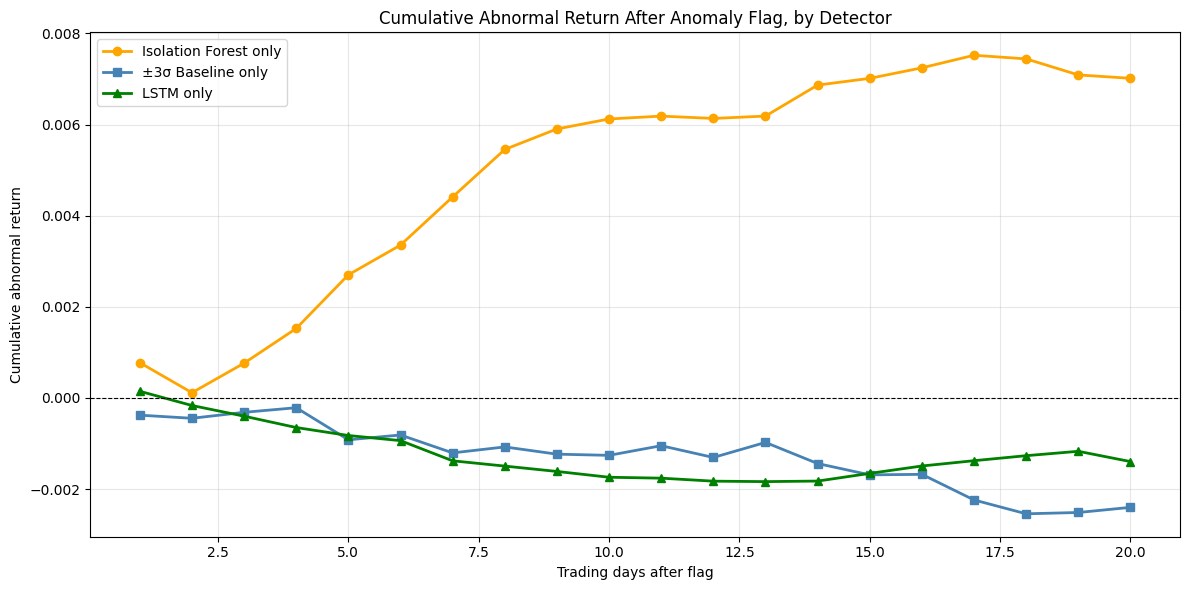

In [21]:
import matplotlib.pyplot as plt

def car_path(flagged_stockdays, abnormal, max_window=20):
    """Average cumulative abnormal return at each day from +1 to +max_window."""
    date_index = abnormal.index
    paths = []
    for (flag_date, ticker) in flagged_stockdays:
        if ticker not in abnormal.columns:
            continue
        loc = date_index.get_indexer([flag_date])[0]
        if loc == -1:
            continue
        start, end = loc + 1, loc + 1 + max_window
        if end > len(date_index):
            continue
        window_abn = abnormal[ticker].iloc[start:end].values
        if len(window_abn) == max_window:
            paths.append(np.cumsum(window_abn))   # running cumulative sum
    return np.array(paths).mean(axis=0)            # average path across all events

iso_path  = car_path(iso_only, abnormal)
stat_path = car_path(stat_only, abnormal)
lstm_path = car_path(lstm_only, abnormal)

days = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, iso_path,  marker="o", label="Isolation Forest only", color="orange", linewidth=2)
ax.plot(days, stat_path, marker="s", label="±3σ Baseline only", color="steelblue", linewidth=2)
ax.plot(days, lstm_path, marker="^", label="LSTM only", color="green", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Abnormal Return After Anomaly Flag, by Detector")
ax.set_xlabel("Trading days after flag")
ax.set_ylabel("Cumulative abnormal return")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig.savefig("../results/event_study_car_paths.png", dpi=150, bbox_inches="tight")

### Event Study: Do Flagged Days Predict Abnormal Returns?

This chart tracks the average cumulative abnormal return (actual return minus what the Fama-French factor model predicts) in the 20 trading days after each detector's unique flags. Measurement starts the day after the flag, since that's the earliest a signal could actually be acted on.

The three detectors diverge sharply. Isolation Forest-only flags are followed by steadily rising abnormal returns, about +0.70% over 20 days, meaning the stock keeps outperforming what the market would predict. That looks like continuation. ±3σ baseline-only and LSTM-only flags drift negative instead, roughly -0.15% to -0.25%, which is mild underperformance consistent with overreaction followed by reversal.

The gap between the Isolation Forest and the baseline is statistically significant (p < 0.001 at 10 and 20 days) and widens over time.

The detectors' disagreements turn out to be economically meaningful, not just statistical. The Isolation Forest identifies states that tend to precede return continuation, while the baseline identifies shocks that tend to precede reversal. Different definitions of "anomalous" carry different, opposite-signed predictive content, which is the core answer to this project's research question.